In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# =========================
# libaries that i will use  
# =========================  

In [3]:
data = pd.read_csv("assignment1dataset.csv")  
data.head(10) 

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
0,7063,76,10,29.84,2713.95
1,44372,66,45,16.72,5744.99
2,19255,37,17,14.30,4101.24
3,13265,14,41,32.82,3009.14
4,13375,26,18,11.92,3279.17
5,37377,26,32,16.24,4687.67
6,38638,92,14,21.01,5526.83
7,34950,60,18,28.24,4116.32
8,29741,99,44,13.08,5841.65
9,17467,42,36,28.84,3419.13


In [5]:
y = data["Energy Consumption"].values
print(y)

[2713.95 5744.99 4101.24 3009.14 3279.17 4687.67 5526.83 4116.32 5841.65
 3419.13 4318.61 5206.34 4070.21 2571.98 5031.14 3891.12 3362.42 5672.37
 3563.67 3080.67 4993.7  4750.37 4134.35 3930.14 4411.53 4812.15 3342.21
 5754.96 3566.01 3409.14 4230.09 4700.42 3991.89 4190.25 2205.2  4483.83
 2733.45 5151.75 2086.62 5038.34 4892.22 3882.94 4015.46 3985.45 6493.48
 4430.49 5428.56 2914.3  6028.93 3791.16 3872.54 2621.96 4526.12 2499.
 2417.11 5505.97 5134.71 5794.31 4329.5  4923.27 4027.56 3753.31 5868.84
 2968.2  3511.71 4307.72 3403.93 4722.68 3580.93 5042.08 6133.65 4999.76
 2451.63 4355.96 3495.35 5043.32 3915.71 4745.47 4944.4  5571.47 3540.91
 4435.54 5359.38 4290.61 3787.26 3927.94 4805.17 2608.53 2497.72 3448.03
 3465.03 3501.94 4209.18 3518.13 5185.62 2599.86 2728.63 2961.76 3855.63
 5343.05 4158.47 3796.71 2648.85 2656.26 2724.82 4015.3  3722.8  4172.08
 4246.55 2109.01 3811.73 2980.23 3516.18 3344.42 4901.86 4683.04 5973.63
 4757.71 3554.19 5094.1  6041.7  3272.91 3744.59 5589

In [7]:
# =========================
# Feature Scaling (only X)
# =========================

def scale(x):
    return (x - np.mean(x)) / np.std(x)


In [9]:
# =========================
# Simple Linear Regression
# =========================

def simple_lr(x, y, lr, epochs):

    m = 0
    c = 0

    n = len(x)

    mse_list = []

    for i in range(epochs):

        y_pred = m * x + c
        error = y_pred - y

        mse = np.mean(error ** 2)
        mse_list.append(mse)

        dm = (2/n) * np.sum(error * x)
        dc = (2/n) * np.sum(error)

        m = m - lr * dm
        c = c - lr * dc

    return m, c, mse_list


In [11]:
# =========================
# Multiple Linear Regression
# =========================

def multi_lr(x, y, lr, epochs):

    n, f = x.shape

    w = np.zeros(f)
    b = 0

    mse_list = []

    for i in range(epochs):

        y_pred = np.dot(x, w) + b
        error = y_pred - y

        mse = np.mean(error ** 2)
        mse_list.append(mse)

        dw = (2/n) * np.dot(x.T, error)
        db = (2/n) * np.sum(error)

        w = w - lr * dw
        b = b - lr * db

    return w, b, mse_list
  

In [13]:
# =========================
# learn rate and epocch t3reef / titles 
# =========================

lr_list = [0.1, 0.01, 0.001]
epoch_list = [50, 100, 200]

lr_mse = []
epoch_mse = []

titles = [
    "Square Footage",
    "Number of Occupants",
    "Appliances Used",
    "Average Temperature",
    "Multi 1",
    "Multi 2"
]
  

In [15]:
# =========================
# Simple Regression Models
# =========================

features = [
    "Square Footage",
    "Number of Occupants",
    "Appliances Used",
    "Average Temperature"
]

print("Simple Linear Regression Results")

for f in features:

    x = data[f].values
    x = scale(x)

    print("\nFeature:", f)

    # Learning Rate Trials
    print("Learning Rate Trials (epochs = 100)")

    mse_lr = []

    for lr in lr_list:

        m, c, mse = simple_lr(x, y, lr, 100)
        mse_lr.append(mse[-1])

        print("LR:", lr, "MSE:", mse[-1])

    lr_mse.append(mse_lr)

    # Epoch Trials
    print("Epoch Trials (learning rate = 0.01)")

    mse_ep = []

    for ep in epoch_list:

        m, c, mse = simple_lr(x, y, 0.01, ep)
        mse_ep.append(mse[-1])

        print("Epoch:", ep, "MSE:", mse[-1])

    epoch_mse.append(mse_ep)



Simple Linear Regression Results

Feature: Square Footage
Learning Rate Trials (epochs = 100)
LR: 0.1 MSE: 347708.83655526984
LR: 0.01 MSE: 675150.726498756
LR: 0.001 MSE: 12376401.428877948
Epoch Trials (learning rate = 0.01)
Epoch: 50 MSE: 2816740.5546477614
Epoch: 100 MSE: 675150.726498756
Epoch: 200 MSE: 353467.8670320725

Feature: Number of Occupants
Learning Rate Trials (epochs = 100)
LR: 0.1 MSE: 760853.1172122058
LR: 0.01 MSE: 1080729.0351141952
LR: 0.001 MSE: 12511607.07478971
Epoch Trials (learning rate = 0.01)
Epoch: 50 MSE: 3172834.636407176
Epoch: 100 MSE: 1080729.0351141952
Epoch: 200 MSE: 766479.0777767223

Feature: Appliances Used
Learning Rate Trials (epochs = 100)
LR: 0.1 MSE: 785062.7874553275
LR: 0.01 MSE: 1104495.350101613
LR: 0.001 MSE: 12519529.93432277
Epoch Trials (learning rate = 0.01)
Epoch: 50 MSE: 3193701.2457215167
Epoch: 100 MSE: 1104495.350101613
Epoch: 200 MSE: 790680.9503112793

Feature: Average Temperature
Learning Rate Trials (epochs = 100)
LR: 0.1 M

In [19]:
# =========================
# Multiple Regression 1
# =========================

print("\nMultiple Linear Regression 1")

x1 = data[["Square Footage", "Number of Occupants"]].values
x1 = scale(x1)

print("Learning Rate Trials (epochs = 100)")

mse_lr = []

for lr in lr_list:

    w, b, mse = multi_lr(x1, y, lr, 100)
    mse_lr.append(mse[-1])

    print("LR:", lr, "MSE:", mse[-1])

lr_mse.append(mse_lr)

print("Epoch Trials (learning rate = 0.01)")

mse_ep = []

for ep in epoch_list:

    w, b, mse = multi_lr(x1, y, 0.01, ep)
    mse_ep.append(mse[-1])

    print("Epoch:", ep, "MSE:", mse[-1])

epoch_mse.append(mse_ep)
# =========================
# Multiple Regression 2
# =========================

print("\nMultiple Linear Regression 2")

x2 = data[["Appliances Used", "Average Temperature"]].values
x2 = scale(x2)

print("Learning Rate Trials (epochs = 100)")

mse_lr = []

for lr in lr_list:

    w, b, mse = multi_lr(x2, y, lr, 100)
    mse_lr.append(mse[-1])

    print("LR:", lr, "MSE:", mse[-1])

lr_mse.append(mse_lr)

print("Epoch Trials (learning rate = 0.01)")

mse_ep = []

for ep in epoch_list:

    w, b, mse = multi_lr(x2, y, 0.01, ep)
    mse_ep.append(mse[-1])

    print("Epoch:", ep, "MSE:", mse[-1])

epoch_mse.append(mse_ep)




Multiple Linear Regression 1
Learning Rate Trials (epochs = 100)
LR: 0.1 MSE: 349586.61263048294
LR: 0.01 MSE: 454559.60643122636
LR: 0.001 MSE: 7317972.460916592
Epoch Trials (learning rate = 0.01)
Epoch: 50 MSE: 746531.5695815424
Epoch: 100 MSE: 454559.60643122636
Epoch: 200 MSE: 363588.2777370652

Multiple Linear Regression 2
Learning Rate Trials (epochs = 100)
LR: 0.1 MSE: 784870.8812414181
LR: 0.01 MSE: 1127528.6590607236
LR: 0.001 MSE: 12275625.449326236
Epoch Trials (learning rate = 0.01)
Epoch: 50 MSE: 3094208.267415462
Epoch: 100 MSE: 1127528.6590607236
Epoch: 200 MSE: 802110.4549414258


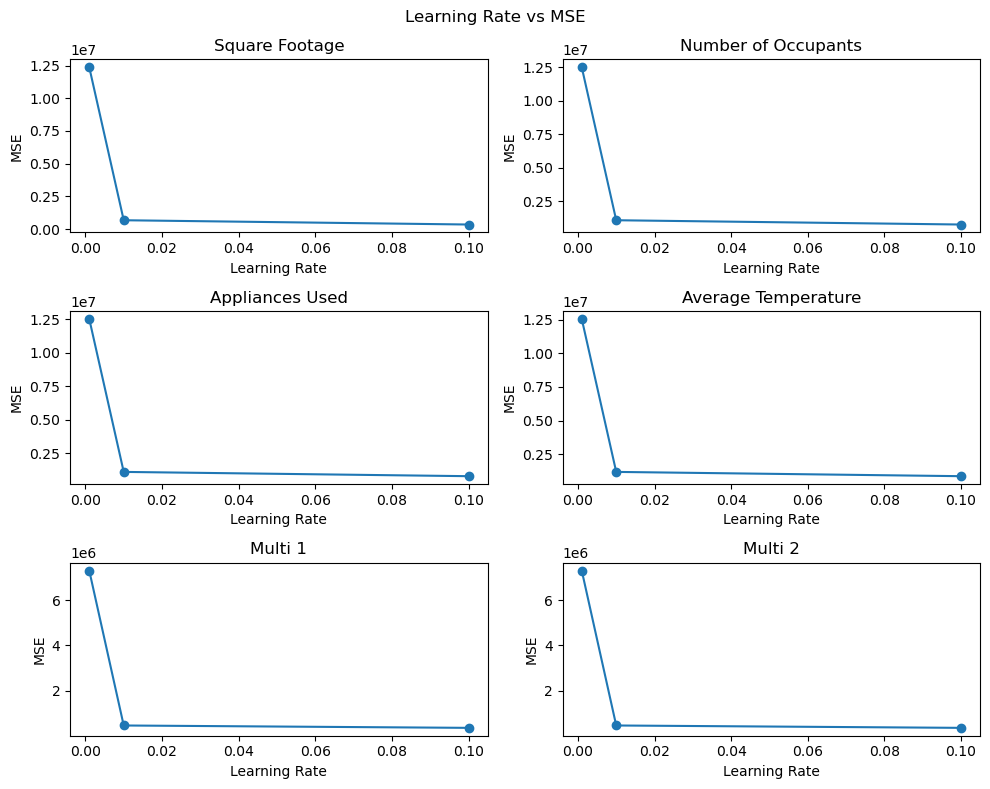

In [21]:
# =========================
# Plot LR vs MSE
# =========================

plt.figure(figsize=(10,8))

for i in range(6):

    plt.subplot(3,2,i+1)
    plt.plot(lr_list, lr_mse[i], marker='o')
    plt.title(titles[i])
    plt.xlabel("Learning Rate")
    plt.ylabel("MSE")

plt.suptitle("Learning Rate vs MSE")

plt.tight_layout()
plt.show()

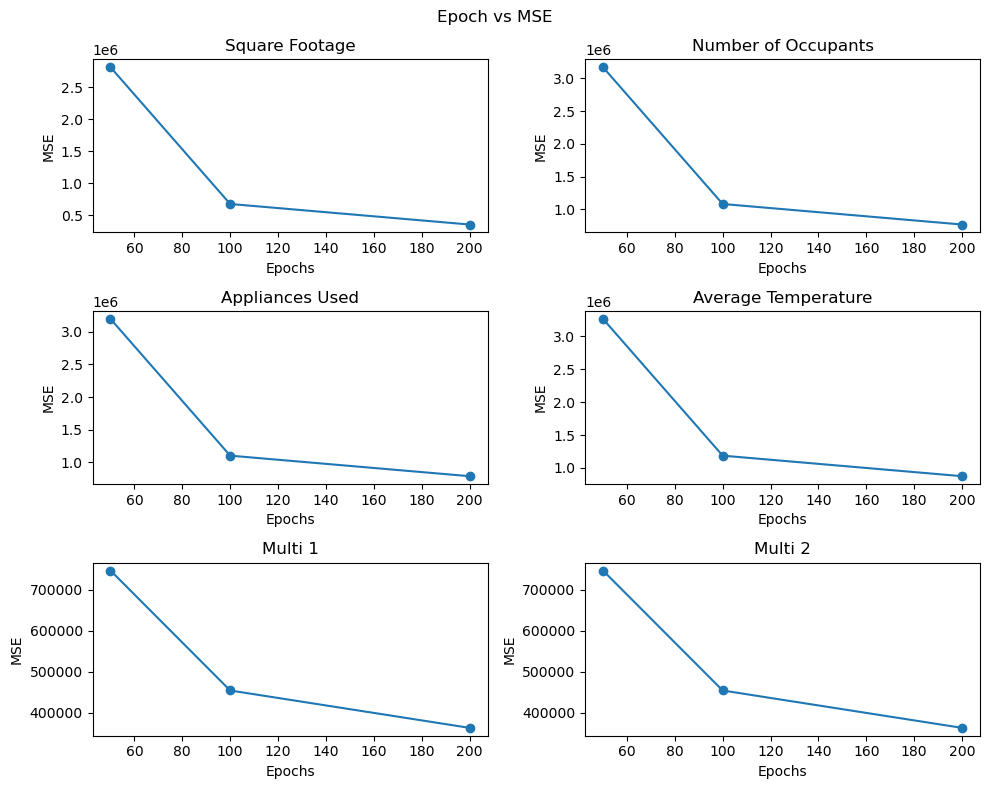

In [23]:

# =========================
# Plot Epoch vs MSE
# =========================

plt.figure(figsize=(10,8))

for i in range(6):

    plt.subplot(3,2,i+1)
    plt.plot(epoch_list, epoch_mse[i], marker='o')
    plt.title(titles[i])
    plt.xlabel("Epochs")
    plt.ylabel("MSE")

plt.suptitle("Epoch vs MSE")

plt.tight_layout()
plt.show()